# Final Report: Particle Swarm Optimization in Python

This notebook is the narrated final report for the PSO project. It
documents the experimental methodology, loads the saved results, compares
the implemented execution strategies, and closes with a critical discussion
and practical recommendations.

## 1. Project Goal

The goal of the project is to implement a maintainable Particle Swarm
Optimization solution in Python and use it as a laboratory for comparing
different execution strategies while keeping the optimization core shared.

The final codebase focuses on three comparable variants:

- `V0`: sequential baseline
- `V1`: `ThreadPoolExecutor` evaluation
- `V2`: `ProcessPoolExecutor` evaluation

The rest of the report evaluates how these choices affect runtime,
convergence behavior, and experimental reproducibility.

## 2. Experimental Methodology

### 2.1 Shared PSO Core

All variants use the same PSO implementation, the same update equations,
the same boundary handling, and the same topology. Only the fitness
evaluation backend changes. This is essential for a fair comparison because
it isolates timing differences from optimization-quality differences.

### 2.2 Benchmark Protocol

The benchmark suite evaluates four standard objective functions:

- `Sphere`
- `Rosenbrock`
- `Rastrigin`
- `Ackley`

The benchmark dimensions are `2`, `10`, and `30`. The benchmark YAML uses a
fixed iteration budget, so the strategy comparison is not distorted by early
stopping. Tolerance is still recorded as an analysis metric through
`convergence_iteration`, but it does not terminate benchmark runs.

### 2.3 Grid Search Protocol

The grid search explores combinations of:

- inertia `w`
- cognitive coefficient `c1`
- social coefficient `c2`
- swarm size
- iteration budget

The current configuration runs the reduced search space for `V0`, `V1`, and
`V2`, again with fixed iteration budgets and fixed seeds.

### 2.4 Metrics

The comparison relies on six main metrics:

- final best fitness
- AUC of the best-fitness curve
- convergence iteration
- total runtime
- speedup and efficiency relative to `V0`
- accumulated parallel overhead

These metrics let us compare not only final solution quality but also how
quickly the optimizer reaches good solutions and how much execution overhead
is introduced by the parallel backends.

In [1]:
from itertools import product
from pathlib import Path
import json

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import yaml

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

benchmark_cfg = yaml.safe_load((ROOT / 'configs' / 'benchmark.yaml').read_text())
grid_cfg = yaml.safe_load((ROOT / 'configs' / 'grid_search.yaml').read_text())

variant_order = ['V0', 'V1', 'V2']
variant_colors = {
    'V0': '#F4A261',
    'V1': '#4C78A8',
    'V2': '#2A9D8F',
}
variant_labels = {
    'V0': 'sequential',
    'V1': 'threading',
    'V2': 'multiprocessing',
}

variants = [variant for variant in variant_order if variant in benchmark_cfg['strategies']]
objectives = [item['name'] for item in benchmark_cfg['objectives']]
dimensions = benchmark_cfg['dimensions']
benchmark_seeds = benchmark_cfg['seeds']

cases = pd.DataFrame(
    product(variants, objectives, dimensions, benchmark_seeds),
    columns=['variant', 'objective', 'dimensions', 'seed'],
)
cases.head()

,variant,objective,dimensions,seed
0,V0,sphere,2,11
1,V0,sphere,2,23
2,V0,sphere,2,37
3,V0,sphere,10,11
4,V0,sphere,10,23


### 2.5 Cartesian Product Of Benchmark Cases

In [2]:
cases.shape, cases.head(12)

((108, 4),
    variant   objective  dimensions  seed
 0       V0      sphere           2    11
 1       V0      sphere           2    23
 2       V0      sphere           2    37
 3       V0      sphere          10    11
 4       V0      sphere          10    23
 5       V0      sphere          10    37
 6       V0      sphere          30    11
 7       V0      sphere          30    23
 8       V0      sphere          30    37
 9       V0  rosenbrock           2    11
 10      V0  rosenbrock           2    23
 11      V0  rosenbrock           2    37)

## 3. Loading Saved Artifacts

In [3]:
def load_json(path: Path):
    return json.loads(path.read_text())

def resolve_run_dir(run_dir: str) -> Path:
    run_path = Path(run_dir)
    return run_path if run_path.is_absolute() else ROOT / run_path

benchmark_summary_path = ROOT / 'results' / 'benchmarks' / 'benchmark_summary.csv'
benchmark_runs_path = ROOT / 'results' / 'benchmarks' / 'benchmark_runs.csv'
grid_summary_path = ROOT / 'results' / 'grid_search' / 'grid_search_summary.csv'

benchmark_summary = pd.read_csv(benchmark_summary_path) if benchmark_summary_path.exists() else pd.DataFrame()
benchmark_runs = pd.read_csv(benchmark_runs_path) if benchmark_runs_path.exists() else pd.DataFrame()
grid_summary = pd.read_csv(grid_summary_path) if grid_summary_path.exists() else pd.DataFrame()

benchmark_summary.head()

,variant,objective,dimensions,runs,mean_best_value,std_best_value,mean_total_time,mean_auc,mean_convergence_iteration
0,V0,ackley,2,3,4.492965e-08,3.460454e-08,0.160320,62.382375,150.0
1,V1,ackley,2,3,4.492965e-08,3.460454e-08,0.394403,62.382375,150.0
2,V2,ackley,2,3,4.492965e-08,3.460454e-08,0.574920,62.382375,150.0
3,V0,ackley,10,3,1.501011e-03,2.684466e-04,0.168564,362.527414,150.0
4,V1,ackley,10,3,1.501011e-03,2.684466e-04,0.399679,362.527414,150.0


### 3.1 Recorded Execution Conditions

To avoid misleading micro-benchmarks, the project stores system information
and commit metadata in each saved run. The cell below shows one representative
example from the saved benchmark outputs.

In [4]:
sample_summary = None
if not benchmark_runs.empty:
    sample_run_dir = resolve_run_dir(benchmark_runs.iloc[0]['run_dir'])
    sample_summary = load_json(sample_run_dir / 'summary.json')
    display({
        'run_id': sample_summary['run_id'],
        'git_commit': sample_summary['git']['commit'],
        'system': sample_summary['system'],
    })
else:
    print('No benchmark runs are available yet.')

{'run_id': 'V0_sphere_d2_s11_20260407_181318',
 'git_commit': '7294246',
 'system': {'platform': 'Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.39',
  'python_version': '3.12.3',
  'machine': 'x86_64',
  'processor': 'x86_64',
  'cpu_count': 22}}

## 4. Benchmark Results

The benchmark summary is the first high-level view of the comparison. Since
the PSO core is shared, similar final-fitness values across strategies are
expected. The most important differences should appear in runtime and
parallel overhead.

In [5]:
if not benchmark_summary.empty:
    display(benchmark_summary.sort_values(['objective', 'dimensions', 'variant']))
else:
    print('No benchmark summary is available yet.')

,variant,objective,dimensions,runs,mean_best_value,std_best_value,mean_total_time,mean_auc,mean_convergence_iteration
0,V0,ackley,2,3,4.492965e-08,3.460454e-08,0.160320,62.382375,150.000000
1,V1,ackley,2,3,4.492965e-08,3.460454e-08,0.394403,62.382375,150.000000
2,V2,ackley,2,3,4.492965e-08,3.460454e-08,0.574920,62.382375,150.000000
3,V0,ackley,10,3,1.501011e-03,2.684466e-04,0.168564,362.527414,150.000000
4,V1,ackley,10,3,1.501011e-03,2.684466e-04,0.399679,362.527414,150.000000
5,V2,ackley,10,3,1.501011e-03,2.684466e-04,0.552975,362.527414,150.000000
6,V0,ackley,30,3,2.732599e+00,6.986939e-01,0.169470,1211.852515,150.000000
7,V1,ackley,30,3,2.732599e+00,6.986939e-01,0.394393,1211.852515,150.000000
8,V2,ackley,30,3,2.732599e+00,6.986939e-01,0.579642,1211.852515,150.000000
9,V0,rastrigin,2,3,1.610564e-13,1.836753e-13,0.125779,37.329684,95.666667


### 4.1 Best Variant By Runtime

In [6]:
if not benchmark_summary.empty:
    runtime_winners = (
        benchmark_summary.sort_values('mean_total_time')
        .groupby(['objective', 'dimensions'], as_index=False)
        .first()[['objective', 'dimensions', 'variant', 'mean_total_time']]
        .rename(columns={'variant': 'winner_variant'})
    )
    display(runtime_winners)
else:
    print('No benchmark summary is available yet.')

,objective,dimensions,winner_variant,mean_total_time
0,ackley,2,V0,0.160320
1,ackley,10,V0,0.168564
2,ackley,30,V0,0.169470
3,rastrigin,2,V0,0.125779
4,rastrigin,10,V0,0.150058
5,rastrigin,30,V0,0.141300
6,rosenbrock,2,V0,0.122401
7,rosenbrock,10,V0,0.116156
8,rosenbrock,30,V0,0.104894
9,sphere,2,V0,0.081646


## 5. Convergence Analysis

A single convergence chart with every case on top of each other is hard to
read. The notebook therefore splits convergence into panels by objective and
dimension so each subplot compares only the three execution variants.

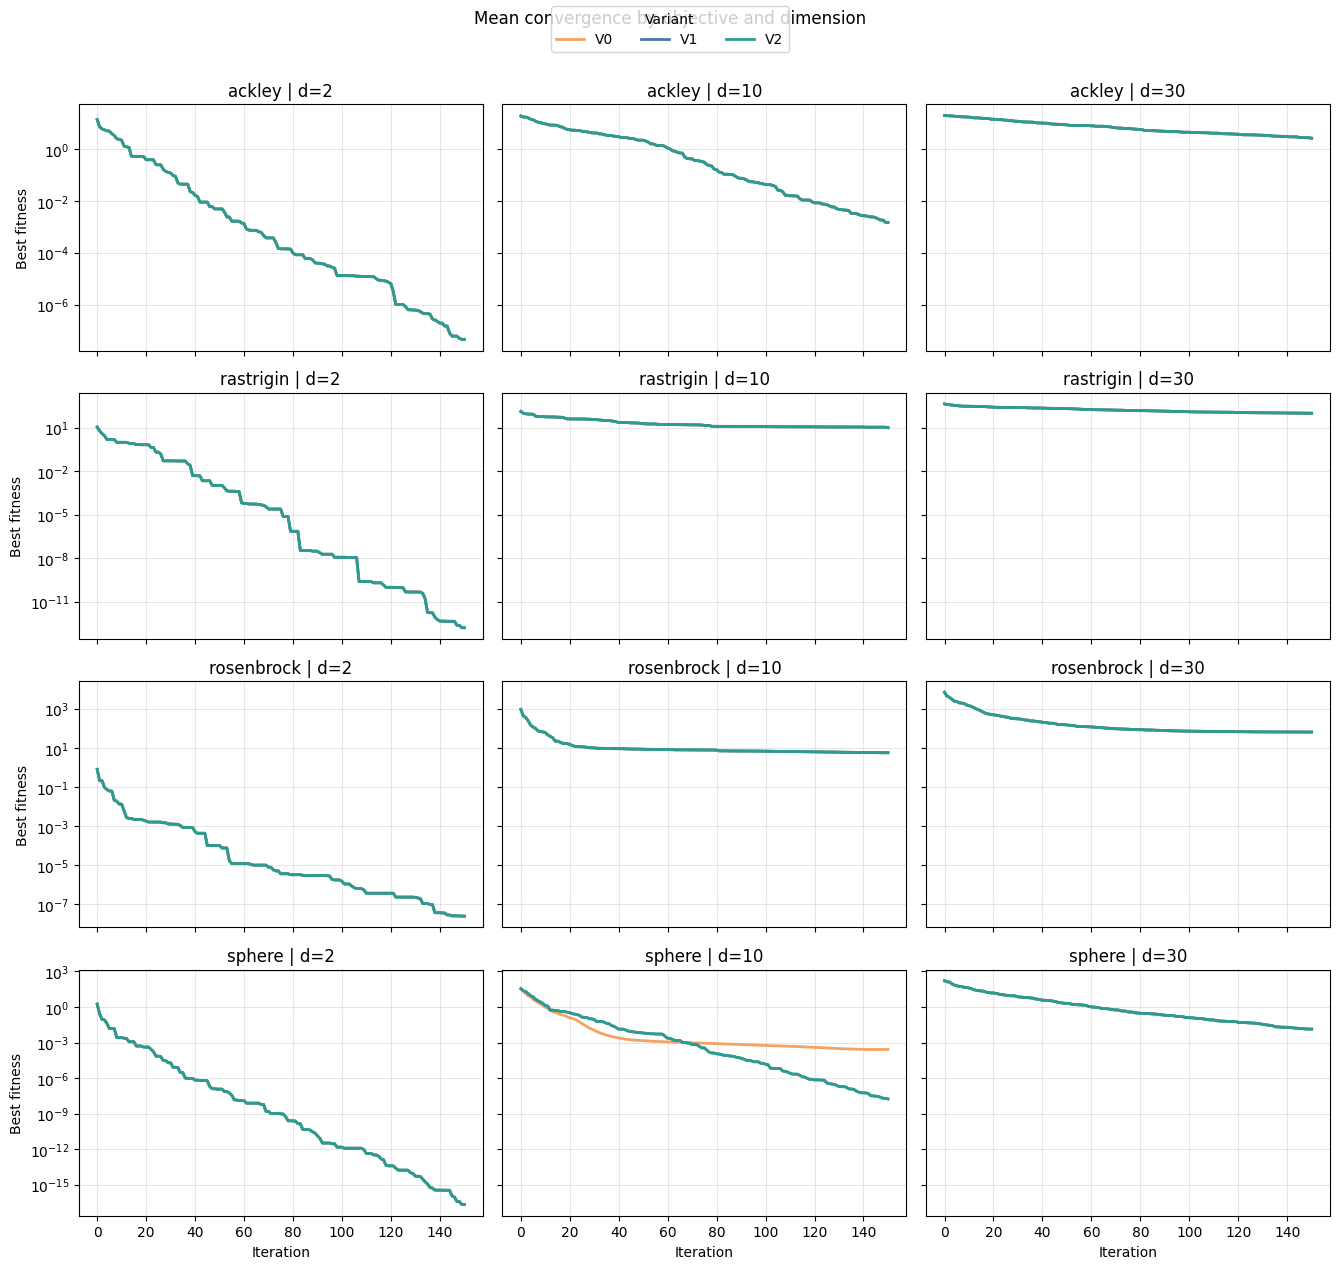

In [7]:
def load_history(run_dir: str) -> pd.DataFrame:
    return pd.read_csv(resolve_run_dir(run_dir) / 'history.csv')

def mean_history_curve(bucket: pd.DataFrame):
    histories = []
    for run_dir in bucket['run_dir']:
        history = load_history(run_dir)
        histories.append(history['best_fitness'].to_numpy())
    if not histories:
        return None
    max_len = max(len(curve) for curve in histories)
    padded = []
    for curve in histories:
        if len(curve) < max_len:
            curve = np.pad(curve, (0, max_len - len(curve)), mode='edge')
        padded.append(curve)
    return np.vstack(padded).mean(axis=0)

if not benchmark_runs.empty:
    objective_order = sorted(benchmark_runs['objective'].unique())
    dimension_order = sorted(benchmark_runs['dimensions'].unique())

    fig, axes = plt.subplots(
        len(objectives),
        len(dimension_order),
        figsize=(4.5 * len(dimension_order), 3.1 * len(objective_order)),
        sharex=True,
        sharey='row',
    )
    axes = np.atleast_2d(axes)

    for row_idx, objective in enumerate(objective_order):
        for col_idx, dimension in enumerate(dimension_order):
            ax = axes[row_idx, col_idx]
            subset = benchmark_runs[
                (benchmark_runs['objective'] == objective)
                & (benchmark_runs['dimensions'] == dimension)
            ]
            for variant in variants:
                curve = mean_history_curve(subset[subset['variant'] == variant])
                if curve is None:
                    continue
                ax.plot(curve, color=variant_colors[variant], linewidth=2, label=variant)
            ax.set_yscale('log')
            ax.set_title(f'{objective} | d={dimension}')
            ax.grid(alpha=0.3)
            if row_idx == len(objective_order) - 1:
                ax.set_xlabel('Iteration')
            if col_idx == 0:
                ax.set_ylabel('Best fitness')

    line_handles = [
        Line2D([0], [0], color=variant_colors[variant], linewidth=2, label=variant)
        for variant in variants
    ]
    fig.suptitle('Mean convergence by objective and dimension', y=1.02)
    fig.legend(handles=line_handles, loc='upper center', ncol=len(variants), title='Variant')
    plt.tight_layout()
    plt.show()
else:
    print('No benchmark run data is available yet.')

## 6. Final Fitness Distribution

One overall boxplot is useful as a quick summary, but the detailed analysis
benefits from separate boxplots by objective and dimension. The notebook
therefore shows both a global view and a faceted view.

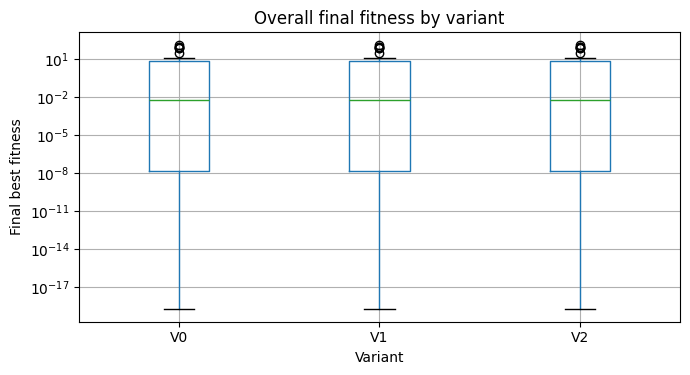

/tmp/ipykernel_147687/2227820881.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax.boxplot(box_data, patch_artist=True, labels=labels, showfliers=True)
/tmp/ipykernel_147687/2227820881.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax.boxplot(box_data, patch_artist=True, labels=labels, showfliers=True)
/tmp/ipykernel_147687/2227820881.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax.boxplot(box_data, patch_artist=True, labels=labels, showfliers=True)
/tmp/ipykernel_147687/2227820881.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been rename

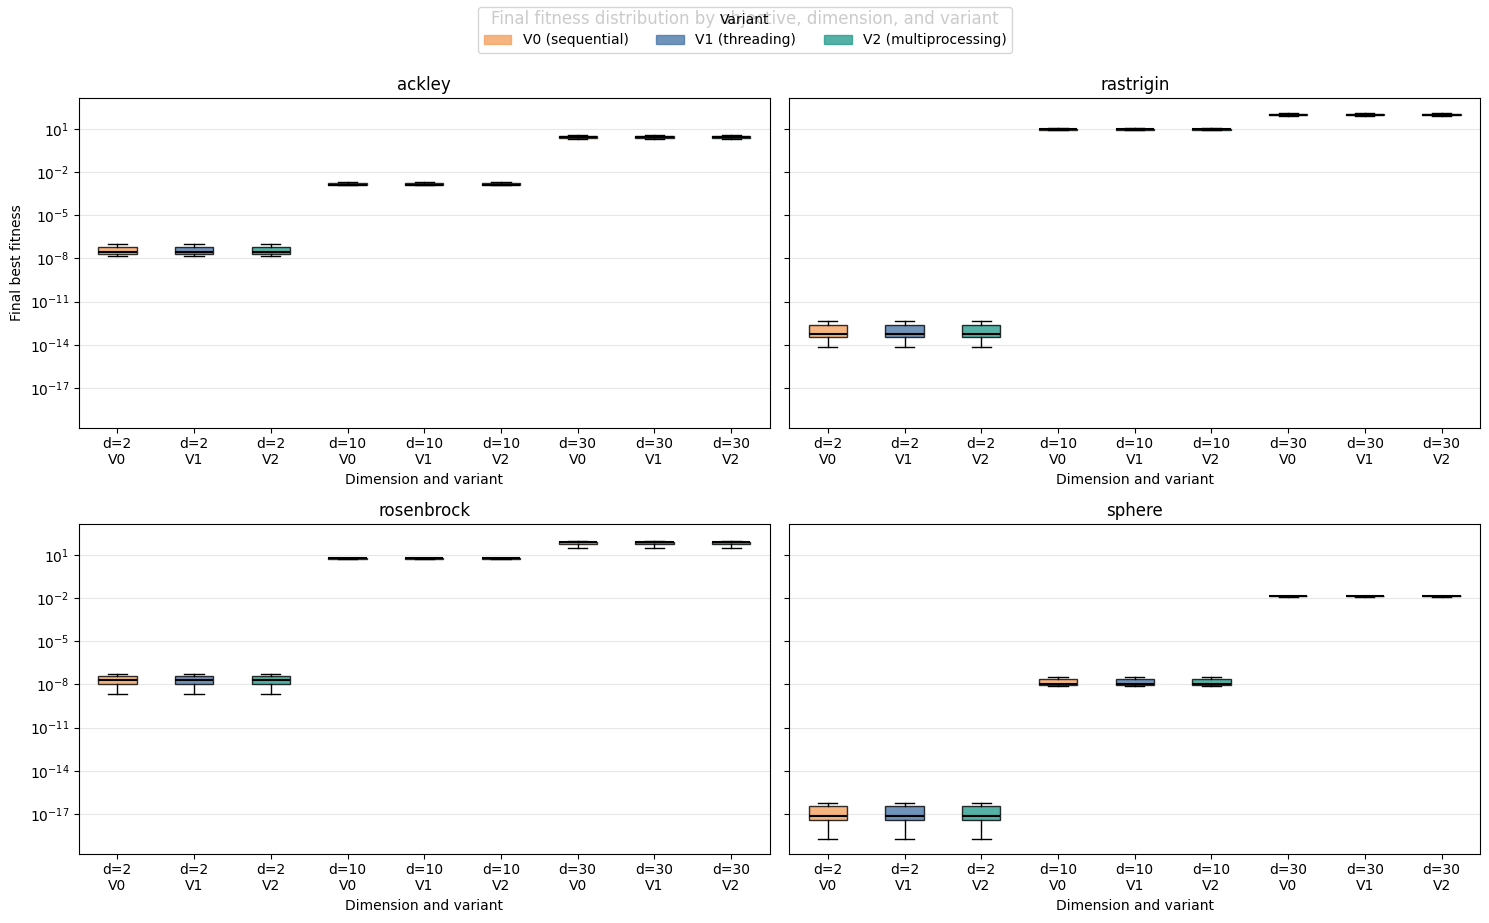

In [8]:
if not benchmark_runs.empty:
    fig, ax = plt.subplots(figsize=(7, 4))
    benchmark_runs.boxplot(column='best_value', by='variant', ax=ax)
    ax.set_yscale('log')
    ax.set_title('Overall final fitness by variant')
    ax.set_xlabel('Variant')
    ax.set_ylabel('Final best fitness')
    plt.suptitle('')
    plt.tight_layout()
    plt.show()

    objective_order = sorted(benchmark_runs['objective'].unique())
    dimension_order = sorted(benchmark_runs['dimensions'].unique())
    fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharey=True)
    axes = axes.ravel()

    for ax, objective in zip(axes, objective_order):
        box_data = []
        labels = []
        colors = []
        for dimension in dimension_order:
            for variant in variants:
                values = benchmark_runs[
                    (benchmark_runs['objective'] == objective)
                    & (benchmark_runs['dimensions'] == dimension)
                    & (benchmark_runs['variant'] == variant)
                ]['best_value'].to_numpy()
                if len(values) == 0:
                    continue
                box_data.append(values)
                labels.append(f'd={dimension}\n{variant}')
                colors.append(variant_colors[variant])

        boxplot = ax.boxplot(box_data, patch_artist=True, labels=labels, showfliers=True)
        for patch, color in zip(boxplot['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.8)
        for median in boxplot['medians']:
            median.set_color('black')
            median.set_linewidth(1.5)

        ax.set_yscale('log')
        ax.set_title(objective)
        ax.set_xlabel('Dimension and variant')
        ax.grid(axis='y', alpha=0.3)

    legend_handles = [
        Patch(facecolor=variant_colors[variant], edgecolor=variant_colors[variant], alpha=0.8, label=f'{variant} ({variant_labels[variant]})')
        for variant in variants
    ]
    axes[0].set_ylabel('Final best fitness')
    fig.suptitle('Final fitness distribution by objective, dimension, and variant', y=1.02)
    fig.legend(handles=legend_handles, loc='upper center', ncol=len(variants), title='Variant')
    plt.tight_layout()
    plt.show()
else:
    print('No benchmark run data is available yet.')

## 7. Runtime, Speedup, And Efficiency

The most important difference between variants in this project is runtime.
The notebook keeps the summary table, but it also adds a grouped bar chart
of speedup vs sequential for each objective and dimension, which is much
easier to read in the final report.

,objective,dimensions,variant,workers,mean_total_time,speedup_vs_V0,efficiency
0,ackley,2,V0,1,0.160320,1.000000,1.000000
1,ackley,2,V1,4,0.394403,0.406487,0.101622
2,ackley,2,V2,4,0.574920,0.278856,0.069714
3,ackley,10,V0,1,0.168564,1.000000,1.000000
4,ackley,10,V1,4,0.399679,0.421748,0.105437
5,ackley,10,V2,4,0.552975,0.304831,0.076208
6,ackley,30,V0,1,0.169470,1.000000,1.000000
7,ackley,30,V1,4,0.394393,0.429697,0.107424
8,ackley,30,V2,4,0.579642,0.292369,0.073092
9,rastrigin,2,V0,1,0.125779,1.000000,1.000000


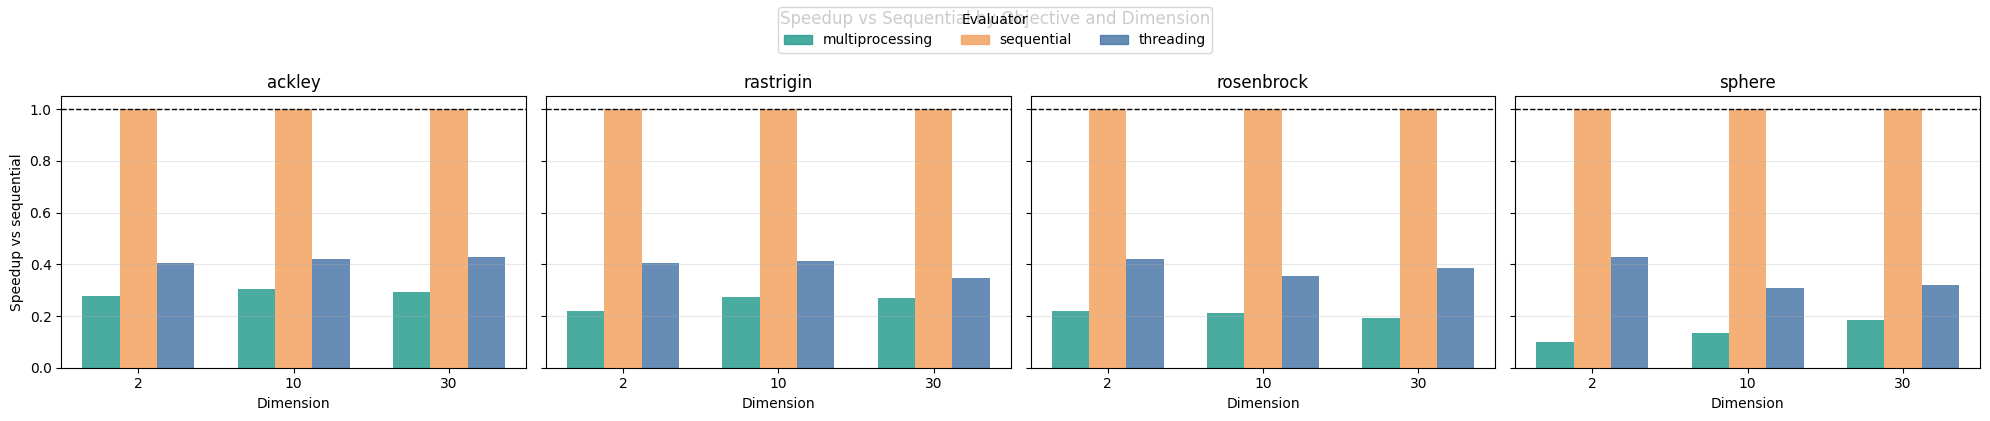

In [9]:
if not benchmark_runs.empty:
    worker_map = {'V0': 1}
    for variant, overrides in benchmark_cfg['strategies'].items():
        worker_map[variant] = overrides.get('workers', 1)

    speedup_rows = []
    for (objective, dimension), bucket in benchmark_runs.groupby(['objective', 'dimensions']):
        baseline = bucket[bucket['variant'] == 'V0']['total_time'].mean()
        for variant, variant_bucket in bucket.groupby('variant'):
            mean_time = variant_bucket['total_time'].mean()
            speedup = baseline / mean_time if mean_time else None
            workers = worker_map.get(variant, 1)
            efficiency = speedup / workers if workers else None
            speedup_rows.append({
                'objective': objective,
                'dimensions': dimension,
                'variant': variant,
                'workers': workers,
                'mean_total_time': mean_time,
                'speedup_vs_V0': speedup,
                'efficiency': efficiency,
            })

    speedup_df = pd.DataFrame(speedup_rows)
    display(speedup_df.sort_values(['objective', 'dimensions', 'variant']))

    objective_order = sorted(speedup_df['objective'].unique())
    dimension_order = sorted(speedup_df['dimensions'].unique())
    bar_variants = ['V2', 'V0', 'V1']
    x = np.arange(len(dimension_order))
    width = 0.24
    offsets = np.linspace(-width, width, len(bar_variants))

    fig, axes = plt.subplots(1, len(objective_order), figsize=(5 * len(objective_order), 4), sharey=True)
    axes = np.atleast_1d(axes)

    for ax, objective in zip(axes, objective_order):
        objective_df = speedup_df[speedup_df['objective'] == objective]
        for offset, variant in zip(offsets, bar_variants):
            values = []
            for dimension in dimension_order:
                match = objective_df[
                    (objective_df['dimensions'] == dimension)
                    & (objective_df['variant'] == variant)
                ]
                values.append(match['speedup_vs_V0'].iloc[0] if not match.empty else np.nan)
            ax.bar(x + offset, values, width=width, color=variant_colors[variant], alpha=0.85, label=variant_labels[variant])

        ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
        ax.set_title(objective)
        ax.set_xlabel('Dimension')
        ax.set_xticks(x, [str(dimension) for dimension in dimension_order])
        ax.grid(axis='y', alpha=0.3)

    axes[0].set_ylabel('Speedup vs sequential')
    legend_handles = [
        Patch(facecolor=variant_colors[variant], edgecolor=variant_colors[variant], alpha=0.85, label=variant_labels[variant])
        for variant in bar_variants
    ]
    fig.suptitle('Speedup vs Sequential by Objective and Dimension', y=1.04)
    fig.legend(handles=legend_handles, loc='upper center', ncol=len(bar_variants), title='Evaluator')
    plt.tight_layout()
    plt.show()
else:
    print('No benchmark run data is available yet.')

## 8. Overhead Analysis

Parallelization is only useful when the extra coordination cost remains under
control. The next cell reads the per-run summaries and compares the recorded
total overhead accumulated by each strategy.

In [10]:
if not benchmark_runs.empty:
    overhead_rows = []
    for _, row in benchmark_runs.iterrows():
        summary = load_json(resolve_run_dir(row['run_dir']) / 'summary.json')
        overhead_rows.append({
            'variant': row['variant'],
            'objective': row['objective'],
            'dimensions': row['dimensions'],
            'total_overhead_time': summary['metrics']['total_overhead_time'],
        })
    overhead_df = pd.DataFrame(overhead_rows)
    overhead_summary = (
        overhead_df.groupby(['variant', 'dimensions'], as_index=False)['total_overhead_time']
        .mean()
        .rename(columns={'total_overhead_time': 'mean_total_overhead_time'})
    )
    display(overhead_summary.sort_values(['dimensions', 'variant']))
else:
    print('No benchmark run data is available yet.')

,variant,dimensions,mean_total_overhead_time
0,V0,2,0.012095
3,V1,2,0.190679
6,V2,2,0.540574
1,V0,10,0.012255
4,V1,10,0.211654
7,V2,10,0.468792
2,V0,30,0.012055
5,V1,30,0.210349
8,V2,30,0.454824


## 9. Grid Search Results

The grid search ranks hyperparameter combinations according to the selected
metric. In the current configuration, the reduced search space is evaluated
for each strategy so that the search procedure is comparable across `V0`,
`V1`, and `V2`.

In [11]:
if not grid_summary.empty:
    display(grid_summary.sort_values(['variant', 'mean_best_value']).head(15))
else:
    print('No grid-search summary is available yet.')

,variant,config_index,runs,mean_best_value,std_best_value,mean_total_time,mean_auc,mean_convergence_iteration,inertia,cognitive,social,swarm_size,iterations
0,V0,2,10,4.830312,6.323184,0.091959,1146.409023,132.1,0.5,1.2,1.2,40,150
3,V0,1,10,6.329757,7.615637,0.075281,1352.038076,150.0,0.5,1.2,1.2,30,150
1,V1,2,10,4.830312,6.323184,0.217424,1146.409023,132.1,0.5,1.2,1.2,40,150
4,V1,1,10,6.329757,7.615637,0.162460,1352.038076,150.0,0.5,1.2,1.2,30,150
2,V2,2,10,4.830312,6.323184,0.748501,1146.409023,132.1,0.5,1.2,1.2,40,150
5,V2,1,10,6.329757,7.615637,0.557584,1352.038076,150.0,0.5,1.2,1.2,30,150


## 10. Critical Discussion

### 10.1 GIL And Threading

The thread-based variant is useful for demonstrating that Python threads do
not automatically improve CPU-bound numerical workloads. When the objective
evaluation is dominated by Python-side work, the Global Interpreter Lock can
limit parallel speedup.

### 10.2 IPC And Process Overhead

The process-based variant avoids the GIL for the worker side, but it pays
extra cost in serialization, process startup, synchronization, and inter-
process communication. This overhead matters especially when each task is
too small.

### 10.3 Why Fitness Quality Stays Similar

Because the PSO core is shared and the order of particle results is preserved
by the evaluators, optimization quality remains the same or nearly the same
across `V0`, `V1`, and `V2`. This is expected in the current architecture and
is actually desirable for a fair comparison.

### 10.4 Vectorization As A Discussion Point

Vectorization is not part of the final simplified codebase, but it remains an
important discussion point. In many numerical optimization tasks, vectorized
NumPy code can outperform both threads and processes because it reduces Python
loop overhead and delegates work to optimized native routines. It is therefore
a relevant comparison point in the report even if it is not part of the final
mandatory implementation.

### 10.5 Trade-Off Summary

- `V0` is simple, stable, and often best when the workload is small.
- `V1` is pedagogically useful for discussing the GIL, but it is not always faster.
- `V2` is the most promising for heavier workloads, but only when the evaluation cost is large enough to amortize IPC overhead.

## 11. Recommendations

Based on the current implementation and saved benchmark results, the main
practical recommendations are:

- Use `V0` as the default baseline for lightweight problems and debugging.
- Use `V2` when the objective evaluation is expensive enough to justify process overhead.
- Keep benchmark and grid-search runs on fixed iteration budgets so timing comparisons remain fair.
- Record seeds, configuration, and system metadata in every run so experiments stay reproducible.
- Treat vectorization as an important future direction even if it is outside the current simplified scope.

Overall, the codebase behaves as a maintainable PSO laboratory with a shared
optimizer core, structured persistence, reproducible experiments, and clear
separation between optimization logic and evaluation strategy.